# MDEAgent Benchmark Analyse

Dieses Notebook analysiert die Ergebnisse der MDEAgent Benchmark-Durchführung.

**Ziel:**
- Übersicht über die Benchmark-Ausführung
- Identifikation der am häufigsten fehlerhaften Tools/Evaluations
- Analyse der Ausführungszeiten (schnellstes/langsamstes Model)
- Ermittlung, welche Models den Test ohne Abbrüche bestanden haben
- Analyse der Phasen-Dauer via LangFuse API

## 1. Daten laden

In [24]:
import json
import os
import numpy as np
from pathlib import Path
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Pfade
RESULTS_DIR = Path('..') / '.mdeagent-benchmark' / 'results'
MODELS_CSV = Path('..') / '.mdeagent-benchmark' / 'models.csv'
OUTPUT_DIR = Path('..') / 'notebooks' / 'benchmark_results'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Alle Ergebnis-Dateien laden
# Neue Struktur: jede Datei enthält ein JSON-Objekt mit model_id + iteration
# Dateinamen: {model_safe_name}_iter{n}.json
all_results = []
for filepath in sorted(RESULTS_DIR.glob('*_iter*.json')):
    with open(filepath, 'r') as f:
        entry = json.load(f)
        # model_id, iteration sind bereits im JSON
        entry["source_file"] = filepath.stem  # zum Rückverfolgen
        all_results.append(entry)

# In DataFrame konvertieren
df = pd.DataFrame(all_results)
print(f'Gesamtzahl Entries: {len(df)}')
print(f'Anzahl Models: {df["model_id"].nunique()}')
print(f'\nSpalten: {list(df.columns)}')
df.head()


Gesamtzahl Entries: 50
Anzahl Models: 5

Spalten: ['model_id', 'iteration', 'workspace_path', 'timestamp', 'success', 'error', 'trace_id', 'trace_url', 'transformation_class_path', 'bxtool_path', 'written_files', 'evaluation_runs', 'iterations_completed', 'source_file']


,model_id,iteration,workspace_path,timestamp,success,error,trace_id,trace_url,transformation_class_path,bxtool_path,written_files,evaluation_runs,iterations_completed,source_file
0,GaleneAI/Magistral-Small-2509-FP8-Dynamic,1,/var/folders/x7/r2jcv5k52zldy242qw2z17y80000gn...,2026-09-29T10:44:24.142046+00:00,False,"{'type': 'RuntimeError', 'message': 'Maximum i...",None,None,NaN,NaN,[],[],0,GaleneAI-Magistral-Small-2509-FP8-Dynamic_iter1
1,GaleneAI/Magistral-Small-2509-FP8-Dynamic,10,/var/folders/x7/r2jcv5k52zldy242qw2z17y80000gn...,2026-09-29T10:44:24.142140+00:00,False,"{'type': 'RuntimeError', 'message': 'Maximum i...",None,None,NaN,NaN,[],[],0,GaleneAI-Magistral-Small-2509-FP8-Dynamic_iter10
2,GaleneAI/Magistral-Small-2509-FP8-Dynamic,2,/var/folders/x7/r2jcv5k52zldy242qw2z17y80000gn...,2026-09-29T10:44:24.142187+00:00,False,"{'type': 'OpenAITimeoutError', 'message': 'Req...",None,None,NaN,NaN,[],[],0,GaleneAI-Magistral-Small-2509-FP8-Dynamic_iter2
3,GaleneAI/Magistral-Small-2509-FP8-Dynamic,3,/var/folders/x7/r2jcv5k52zldy242qw2z17y80000gn...,2026-09-29T10:44:24.141782+00:00,False,"{'type': 'OpenAITimeoutError', 'message': 'Req...",None,None,NaN,NaN,[],[],0,GaleneAI-Magistral-Small-2509-FP8-Dynamic_iter3
4,GaleneAI/Magistral-Small-2509-FP8-Dynamic,4,/var/folders/x7/r2jcv5k52zldy242qw2z17y80000gn...,2026-09-29T10:44:24.142240+00:00,True,None,None,None,/var/folders/x7/r2jcv5k52zldy242qw2z17y80000gn...,/var/folders/x7/r2jcv5k52zldy242qw2z17y80000gn...,[/var/folders/x7/r2jcv5k52zldy242qw2z17y80000g...,"[workspace_structure, tools_installed, file_ex...",2,GaleneAI-Magistral-Small-2509-FP8-Dynamic_iter4


## 2. Überblick über die Ausführung

In [25]:
# Erfolgsstatistik
success_count = df['success'].sum()
failure_count = len(df) - success_count
success_rate = (success_count / len(df)) * 100

print('=' * 60)
print('ÜBERBLICK: Benchmark-Ergebnisse')
print('=' * 60)
print(f'Gesamtzahl Models:     {len(df)}')
print(f'\u2713 Erfolgreich:         {success_count} ({success_rate:.1f}%)')
print(f'\u2717 Fehlgeschlagen:      {failure_count} ({100-success_rate:.1f}%)')
print('=' * 60)

ÜBERBLICK: Benchmark-Ergebnisse
Gesamtzahl Models:     50
✓ Erfolgreich:         15 (30.0%)
✗ Fehlgeschlagen:      35 (70.0%)


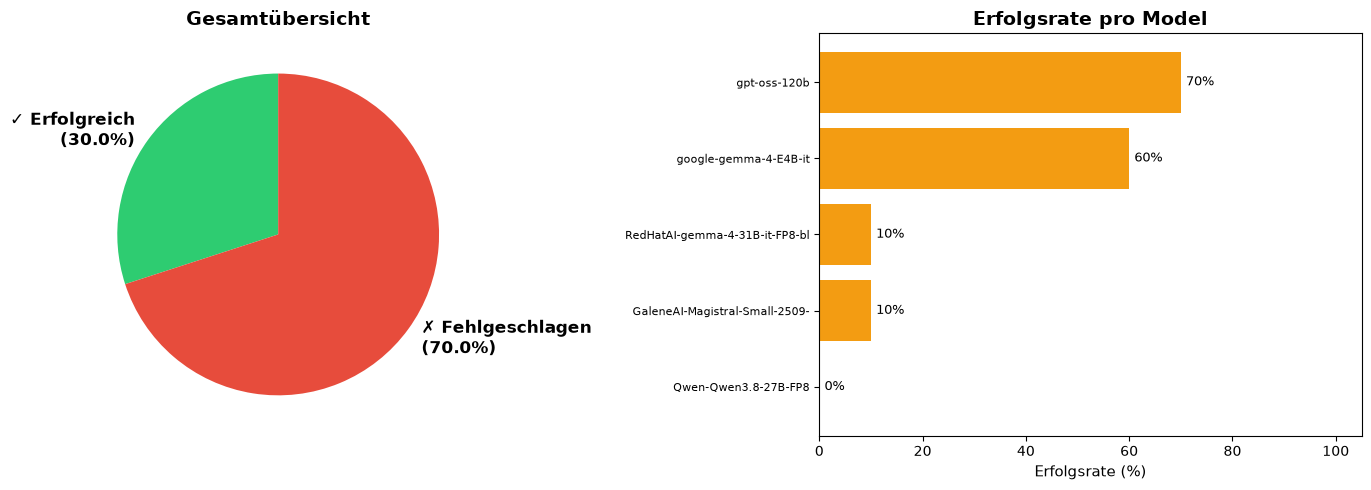

In [26]:
# Diagramm: Erfolgsquote
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Pie Chart
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(
    [success_count, failure_count],
    labels=[f'\u2713 Erfolgreich\n({success_rate:.1f}%)', f'\u2717 Fehlgeschlagen\n({100-success_rate:.1f}%)'],
    colors=colors,
    autopct='',
    startangle=90,
    textprops={'fontsize': 12, 'weight': 'bold'}
)
axes[0].set_title('Gesamtübersicht', fontsize=14, weight='bold')

# 2. Barchart pro Model
model_status = df.groupby('model_id')['success'].agg(['sum', 'count']).reset_index()
model_status.columns = ['model_id', 'success_count', 'total_count']
model_status['rate'] = (model_status['success_count'] / model_status['total_count']) * 100
model_status = model_status.sort_values('rate', ascending=True)

colors_bar = ['#2ecc71' if r == 100 else '#f39c12' if r > 0 else '#e74c3c' for r in model_status['rate']]
axes[1].barh(range(len(model_status)), model_status['rate'], color=colors_bar)
axes[1].set_yticks(range(len(model_status)))
axes[1].set_yticklabels([m.replace('/', '-')[:30] for m in model_status['model_id']], fontsize=8)
axes[1].set_xlabel('Erfolgsrate (%)', fontsize=11)
axes[1].set_title('Erfolgsrate pro Model', fontsize=14, weight='bold')
axes[1].set_xlim(0, 105)
for i, rate in enumerate(model_status['rate']):
    axes[1].text(rate + 1, i, f'{rate:.0f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'benchmark_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Welche Models haben den Test ohne Abbrüche bestanden?

In [27]:
# Models die erfolgreich waren
successful_models = df[df['success'] == True]

print('=' * 60)
print('SUCCESSFUL MODELS (ohne Abbrüche)')
print('=' * 60)
for _, row in successful_models.iterrows():
    print(f'\n\u2713 Model: {row["model_id"]}')
    print(f'  Iteration: {row["iteration"]}')
    print(f'  Completed Iterations: {row["iterations_completed"]}')
    print(f'  Evaluation Runs: {row["evaluation_runs"]}')
    print(f'  Transformation: {Path(row["transformation_class_path"]).name if row["transformation_class_path"] else "N/A"}')
    print(f'  Timestamp: {row["timestamp"]}')
print('\n' + '=' * 60)

SUCCESSFUL MODELS (ohne Abbrüche)

✓ Model: GaleneAI/Magistral-Small-2509-FP8-Dynamic
  Iteration: 4
  Completed Iterations: 2
  Evaluation Runs: ['workspace_structure', 'tools_installed', 'file_existence', 'java_compilation', 'plan_complete', 'transformation_code']
  Transformation: FamiliesToPersonsTransformation.java
  Timestamp: 2026-09-29T10:44:24.142240+00:00

✓ Model: RedHatAI/gemma-4-31B-it-FP8-block
  Iteration: 2
  Completed Iterations: 2
  Evaluation Runs: ['workspace_structure', 'tools_installed', 'file_existence', 'java_compilation', 'plan_complete', 'transformation_code']
  Transformation: FamiliesToPersonsTransformation.java
  Timestamp: 2026-09-29T10:52:33.654251+00:00

✓ Model: google/gemma-4-E4B-it
  Iteration: 10
  Completed Iterations: 2
  Evaluation Runs: ['workspace_structure', 'tools_installed', 'file_existence', 'java_compilation', 'plan_complete', 'transformation_code']
  Transformation: FamiliesToPersonsTransformation.java
  Timestamp: 2026-09-29T10:59:33.1479

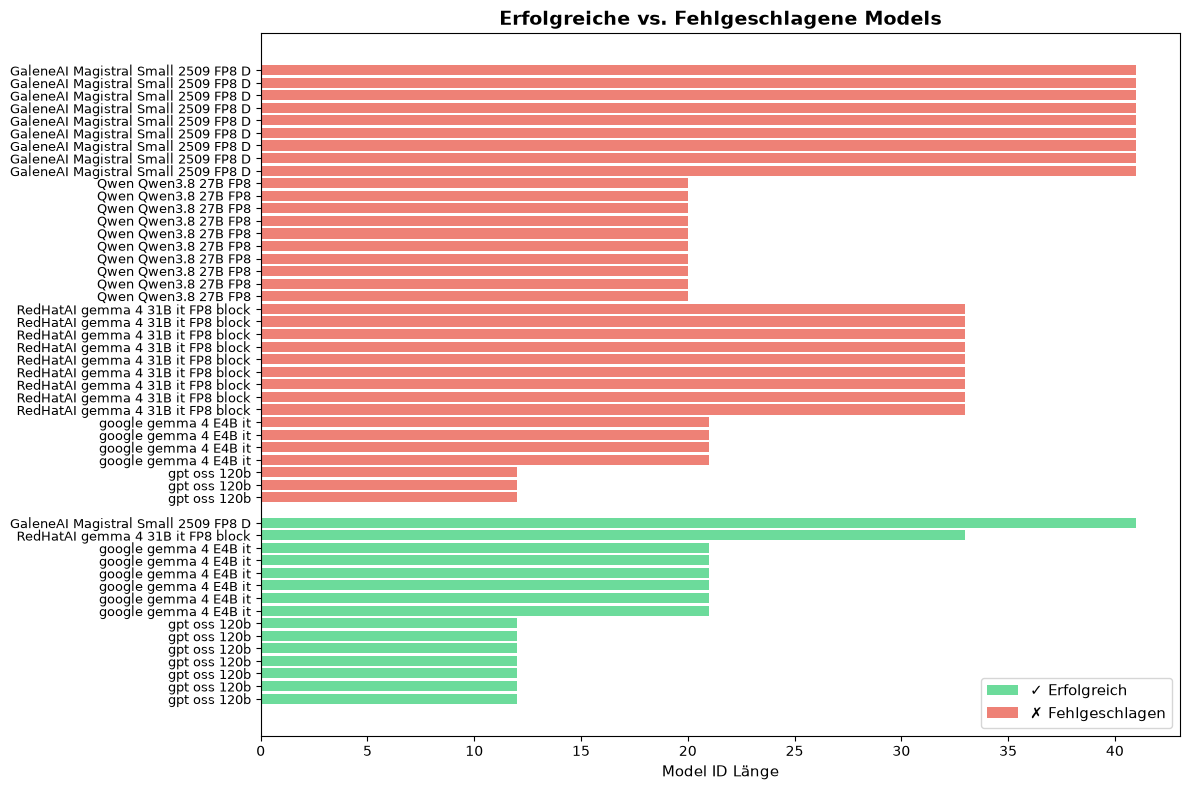

In [28]:
# Diagramm: Erfolgs- vs. Misserfolgs-Models
fig, ax = plt.subplots(figsize=(12, 8))

success_models = df[df['success']]['model_id'].tolist()
failure_models = df[~df['success']]['model_id'].tolist()

y_success = list(range(len(success_models), 0, -1))
y_failure = list(range(len(failure_models) + len(success_models) + 1, len(success_models) + 1, -1))

ax.barh(y_success, [len(m) for m in success_models], color='#2ecc71', alpha=0.7)
ax.barh(y_failure, [len(m) for m in failure_models], color='#e74c3c', alpha=0.7)

all_models = success_models + failure_models
y_all = y_success + y_failure
ax.set_yticks(y_all)
ax.set_yticklabels([m.replace('/', '-').replace('-', ' ')[:35] for m in all_models], fontsize=9)

ax.set_xlabel('Model ID Länge', fontsize=11)
ax.set_title('Erfolgreiche vs. Fehlgeschlagene Models', fontsize=14, weight='bold')
ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', alpha=0.7, label='\u2713 Erfolgreich'),
    Patch(facecolor='#e74c3c', alpha=0.7, label='\u2717 Fehlgeschlagen')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'benchmark_success_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Fehleranalyse: Welche Tools/Evaluations scheitern am häufigsten?

In [29]:
# Fehler-Typen analysieren
error_df = df[df['error'].notna()]
error_types = error_df['error'].apply(lambda x: x.get('type') if isinstance(x, dict) else 'Unknown')
error_type_counts = error_types.value_counts()

print('=' * 60)
print('FEHLERTYPEN (Häufigkeit)')
print('=' * 60)
for error_type, count in error_type_counts.items():
    print(f'{error_type}: {count} Models ({count/len(error_df)*100:.1f}%)')
print('=' * 60)

FEHLERTYPEN (Häufigkeit)
OpenAITimeoutError: 26 Models (74.3%)
RuntimeError: 6 Models (17.1%)
OpenAIConnectionError: 3 Models (8.6%)


In [30]:
# Fehler-Nachrichten analysieren
error_messages = error_df['error'].apply(lambda x: x.get('message', '') if isinstance(x, dict) else '')
message_counts = error_messages.value_counts()

print('\n' + '=' * 60)
print('FEHLERMELDUNGEN (Häufigkeit)')
print('=' * 60)
for msg, count in message_counts.head(10).items():
    print(f'{count}x: {msg[:100]}...')
print('=' * 60)


FEHLERMELDUNGEN (Häufigkeit)
26x: Request timed out....
6x: Maximum iteration count reached (3/3)....
3x: Connection error....


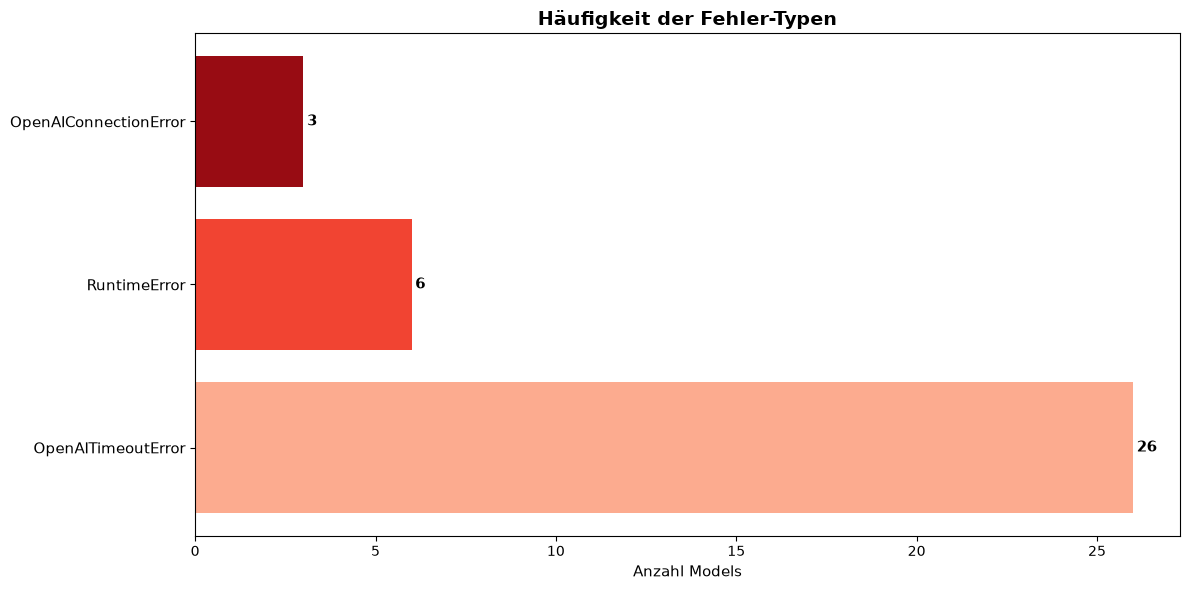

In [31]:
# Diagramm: Fehler-Typen
fig, ax = plt.subplots(figsize=(12, 6))

colors_err = plt.cm.Reds(np.linspace(0.3, 0.9, len(error_type_counts)))
ax.barh(range(len(error_type_counts)), error_type_counts.values, color=colors_err)
ax.set_yticks(range(len(error_type_counts)))
ax.set_yticklabels(error_type_counts.index, fontsize=11)
ax.set_xlabel('Anzahl Models', fontsize=11)
ax.set_title('Häufigkeit der Fehler-Typen', fontsize=14, weight='bold')

for i, count in enumerate(error_type_counts.values):
    ax.text(count + 0.1, i, str(count), va='center', fontsize=11, weight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'benchmark_error_types.png', dpi=150, bbox_inches='tight')
plt.show()

EVALUATION RUNS (erfolgreiche Models)
workspace_structure: 15x durchgeführt
tools_installed: 15x durchgeführt
file_existence: 15x durchgeführt
java_compilation: 15x durchgeführt
plan_complete: 15x durchgeführt
transformation_code: 15x durchgeführt


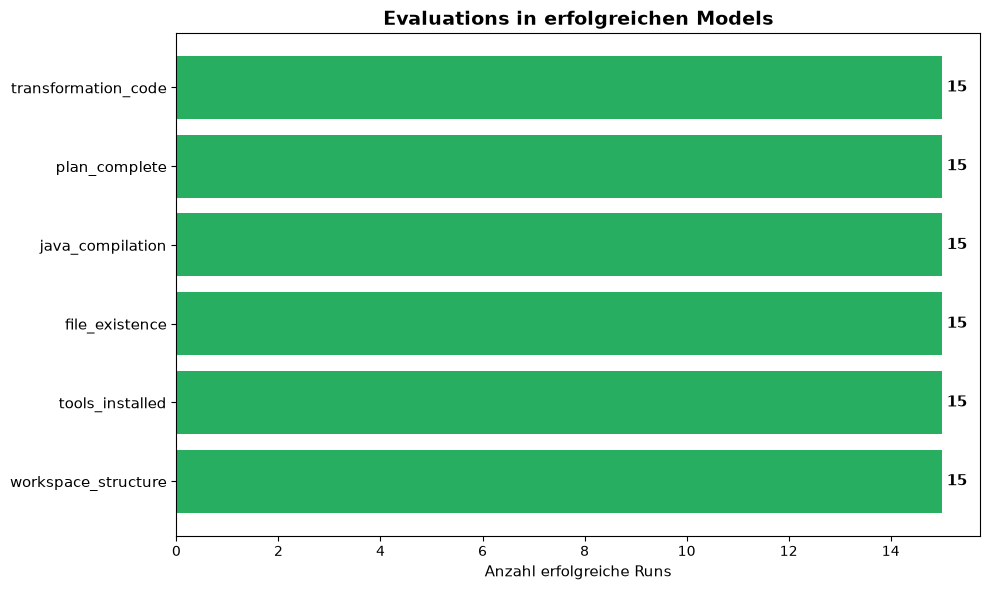

In [32]:
# Evaluationsanalyse für erfolgreiche Models
successful_evals = df[df['success']]['evaluation_runs'].explode().value_counts()

print('=' * 60)
print('EVALUATION RUNS (erfolgreiche Models)')
print('=' * 60)
for eval_run, count in successful_evals.items():
    print(f'{eval_run}: {count}x durchgeführt')
print('=' * 60)

# Diagramm: Evaluations-Durchführung
fig, ax = plt.subplots(figsize=(10, 6))
colors_eval = ['#27ae60' for _ in successful_evals]
ax.barh(range(len(successful_evals)), successful_evals.values, color=colors_eval)
ax.set_yticks(range(len(successful_evals)))
ax.set_yticklabels(successful_evals.index, fontsize=11)
ax.set_xlabel('Anzahl erfolgreiche Runs', fontsize=11)
ax.set_title('Evaluations in erfolgreichen Models', fontsize=14, weight='bold')

for i, count in enumerate(successful_evals.values):
    ax.text(count + 0.1, i, str(count), va='center', fontsize=11, weight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'benchmark_evaluations.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Zeitanalyse: Schnellste und langsamste Models

In [33]:
# Zeitstempel parsen
df['timestamp_dt'] = pd.to_datetime(df['timestamp'], utc=True)
df = df.sort_values('timestamp_dt')

# Da nur 1 Entry pro Model, berechnen wir die relative Ausführungsreihenfolge
df['execution_order'] = range(len(df))

# Zeitdifferenz zum ersten Model
min_time = df['timestamp_dt'].min()
df['time_diff_seconds'] = (df['timestamp_dt'] - min_time).dt.total_seconds()

print('=' * 60)
print('ZEITANALYSE (relative Ausführungsreihenfolge)')
print('=' * 60)
print(f'Benchmark gestartet: {min_time}')
print(f'Benchmark beendet: {df["timestamp_dt"].max()}')
print(f'Gesamtlaufzeit: {df["time_diff_seconds"].max():.1f} Sekunden')
print('=' * 60)

# Schnellstes Model
fastest = df.iloc[0]
print(f'\n\u26a1 Schnellstes Model: {fastest["model_id"]}')
print(f'   Start: {fastest["timestamp"]}')
print(f'   Status: {"\u2713 Erfolg" if fastest["success"] else "\u2717 Fehlgeschlagen"}')

# Langsamstes Model
slowest = df.iloc[-1]
print(f'\n\U0001f40c Langsamstes Model: {slowest["model_id"]}')
print(f'   Start: {slowest["timestamp"]}')
print(f'   Status: {"\u2713 Erfolg" if slowest["success"] else "\u2717 Fehlgeschlagen"}')

# Durchschnittliche Zeit zwischen Starts
avg_time_diff = df['time_diff_seconds'].mean()
print(f'\n\U0001f4ca Durchschnittliche Zeitverschiebung: {avg_time_diff:.1f} Sekunden')

ZEITANALYSE (relative Ausführungsreihenfolge)
Benchmark gestartet: 2026-09-29 10:44:24.141782+00:00
Benchmark beendet: 2026-09-29 11:01:51.547144+00:00
Gesamtlaufzeit: 1047.4 Sekunden

⚡ Schnellstes Model: GaleneAI/Magistral-Small-2509-FP8-Dynamic
   Start: 2026-09-29T10:44:24.141782+00:00
   Status: ✗ Fehlgeschlagen

🐌 Langsamstes Model: Qwen/Qwen3.8-27B-FP8
   Start: 2026-09-29T11:01:51.547144+00:00
   Status: ✗ Fehlgeschlagen

📊 Durchschnittliche Zeitverschiebung: 528.9 Sekunden


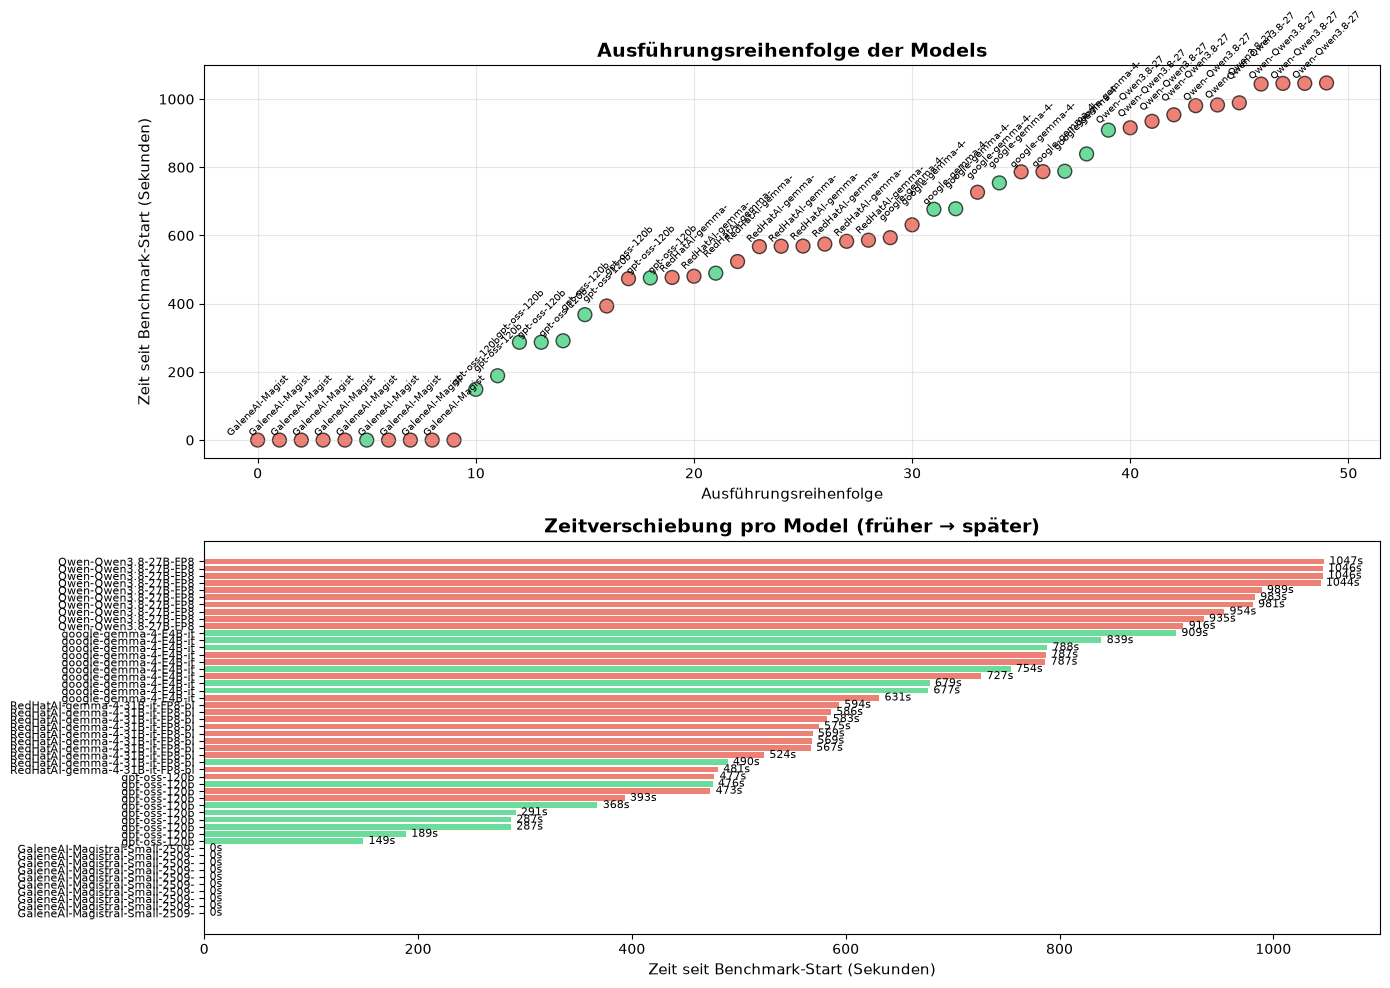

In [34]:
# Diagramm: Ausführungsreihenfolge mit Zeitverschiebung
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1. Ausführungsreihenfolge
colors_order = ['#2ecc71' if s else '#e74c3c' for s in df['success']]
axes[0].scatter(df['execution_order'], df['time_diff_seconds'], c=colors_order, s=100, alpha=0.7, edgecolors='black')
axes[0].set_xlabel('Ausführungsreihenfolge', fontsize=11)
axes[0].set_ylabel('Zeit seit Benchmark-Start (Sekunden)', fontsize=11)
axes[0].set_title('Ausführungsreihenfolge der Models', fontsize=14, weight='bold')
axes[0].grid(True, alpha=0.3)

# Labels hinzufügen
for i, (_, row) in enumerate(df.iterrows()):
    axes[0].text(i, row['time_diff_seconds'] + 5, row['model_id'].replace('/', '-')[:15], 
                ha='center', va='bottom', fontsize=7, rotation=45)

# 2. Zeitverschiebung pro Model
df_sorted = df.sort_values('time_diff_seconds')
colors_bar = ['#2ecc71' if s else '#e74c3c' for s in df_sorted['success']]
axes[1].barh(range(len(df_sorted)), df_sorted['time_diff_seconds'], color=colors_bar, alpha=0.7)
axes[1].set_yticks(range(len(df_sorted)))
axes[1].set_yticklabels([m.replace('/', '-')[:30] for m in df_sorted['model_id']], fontsize=8)
axes[1].set_xlabel('Zeit seit Benchmark-Start (Sekunden)', fontsize=11)
axes[1].set_title('Zeitverschiebung pro Model (fr\u00fcher \u2192 sp\u00e4ter)', fontsize=14, weight='bold')

for i, time in enumerate(df_sorted['time_diff_seconds']):
    axes[1].text(time + 5, i, f'{time:.0f}s', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'benchmark_timing.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# Zusammenfassung der Zeitanalyse
print('=' * 60)
print('ZEITANALYSE ZUSAMMENFASSUNG')
print('=' * 60)
print(f'\n\U0001f4ca Gesamtlaufzeit: {df["time_diff_seconds"].max():.1f} Sekunden ({df["time_diff_seconds"].max()/60:.1f} Minuten)')
print(f'\u26a1 Schnellstes Model: {df.iloc[0]["model_id"]} ({df.iloc[0]["time_diff_seconds"]:.0f}s nach Start)')
print(f'\U0001f40c Langsamstes Model: {df.iloc[-1]["model_id"]} ({df.iloc[-1]["time_diff_seconds"]:.0f}s nach Start)')
print(f'\U0001f4c8 Durchschnittliche Zeitverschiebung: {df["time_diff_seconds"].mean():.1f} Sekunden')
print(f'\U0001f4c9 Median Zeitverschiebung: {df["time_diff_seconds"].median():.1f} Sekunden')
print('=' * 60)

ZEITANALYSE ZUSAMMENFASSUNG

📊 Gesamtlaufzeit: 1047.4 Sekunden (17.5 Minuten)
⚡ Schnellstes Model: GaleneAI/Magistral-Small-2509-FP8-Dynamic (0s nach Start)
🐌 Langsamstes Model: Qwen/Qwen3.8-27B-FP8 (1047s nach Start)
📈 Durchschnittliche Zeitverschiebung: 528.9 Sekunden
📉 Median Zeitverschiebung: 568.8 Sekunden


## 6. Detaillierte Fehleranalyse pro Model

In [36]:
# Alle Failed Models mit ihren Fehlern
failed_models = df[~df['success']].copy()

print('=' * 60)
print('DETAILS: Fehlgeschlagene Models')
print('=' * 60)
for _, row in failed_models.iterrows():
    error_type = row['error'].get('type', 'Unknown') if isinstance(row['error'], dict) else 'Unknown'
    error_msg = row['error'].get('message', '') if isinstance(row['error'], dict) else ''
    print(f'\n\u2717 {row["model_id"]}')
    print(f'  Fehler-Typ: {error_type}')
    print(f'  Fehler-Nachricht: {error_msg[:100]}')
    print(f'  Iterations abgeschlossen: {row["iterations_completed"]}')
print('\n' + '=' * 60)

DETAILS: Fehlgeschlagene Models

✗ GaleneAI/Magistral-Small-2509-FP8-Dynamic
  Fehler-Typ: OpenAITimeoutError
  Fehler-Nachricht: Request timed out.
  Iterations abgeschlossen: 0

✗ GaleneAI/Magistral-Small-2509-FP8-Dynamic
  Fehler-Typ: RuntimeError
  Fehler-Nachricht: Maximum iteration count reached (3/3).
  Iterations abgeschlossen: 0

✗ GaleneAI/Magistral-Small-2509-FP8-Dynamic
  Fehler-Typ: OpenAITimeoutError
  Fehler-Nachricht: Request timed out.
  Iterations abgeschlossen: 0

✗ GaleneAI/Magistral-Small-2509-FP8-Dynamic
  Fehler-Typ: RuntimeError
  Fehler-Nachricht: Maximum iteration count reached (3/3).
  Iterations abgeschlossen: 0

✗ GaleneAI/Magistral-Small-2509-FP8-Dynamic
  Fehler-Typ: OpenAITimeoutError
  Fehler-Nachricht: Request timed out.
  Iterations abgeschlossen: 0

✗ GaleneAI/Magistral-Small-2509-FP8-Dynamic
  Fehler-Typ: OpenAITimeoutError
  Fehler-Nachricht: Request timed out.
  Iterations abgeschlossen: 0

✗ GaleneAI/Magistral-Small-2509-FP8-Dynamic
  Fehler-Typ:

/var/folders/x7/r2jcv5k52zldy242qw2z17y80000gn/T/ipykernel_85719/1735552982.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=error_counts.values, y=error_counts.index, palette='Reds', ax=ax)


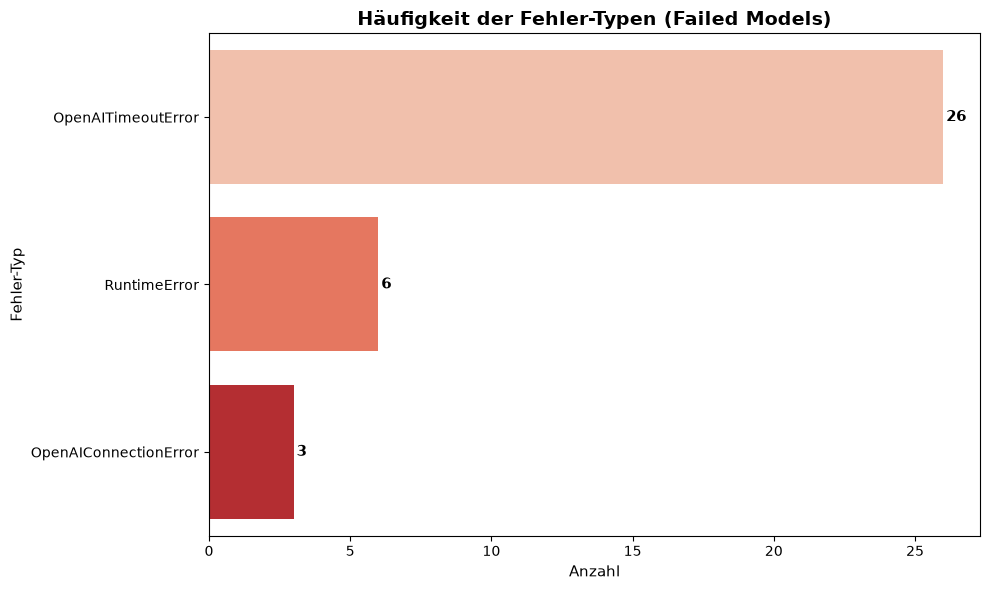

In [37]:
# Einfache Bar-Chart für Fehler-Typen
fig, ax = plt.subplots(figsize=(10, 6))
error_counts = df[df['success'] == False]['error'].apply(
    lambda x: x.get('type', 'Unknown') if isinstance(x, dict) else 'Unknown'
).value_counts()

sns.barplot(x=error_counts.values, y=error_counts.index, palette='Reds', ax=ax)
ax.set_xlabel('Anzahl', fontsize=11)
ax.set_ylabel('Fehler-Typ', fontsize=11)
ax.set_title('Häufigkeit der Fehler-Typen (Failed Models)', fontsize=14, weight='bold')

for i, count in enumerate(error_counts.values):
    ax.text(count + 0.1, i, str(count), va='center', fontsize=11, weight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'benchmark_error_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.5 Phasen-Timing-Analyse via LangFuse API

Dieser Abschnitt fragt die LangFuse API ab, um die Dauer jeder Phase (preparation, comprehension, implementation) zu analysieren.

In [38]:
from dotenv import load_dotenv
from langfuse import Langfuse

# LangFuse verbinden
load_dotenv()

langfuse_client = Langfuse(
    public_key=os.environ['LANGFUSE_PUBLIC_KEY'],
    secret_key=os.environ['LANGFUSE_SECRET_KEY'],
    host=os.environ.get('LANGFUSE_BASE_URL', 'http://localhost:3000'),
)

print('LangFuse verbunden \u2713')
print(f'Host: {os.environ.get("LANGFUSE_BASE_URL", "http://localhost:3000")}')

LangFuse verbunden ✓
Host: http://localhost:3000


In [39]:
# Phasen-Timing-Daten von LangFuse abrufen
phase_data = []

for _, row in df.iterrows():
    model_id = row['model_id']
    is_success = row['success']
    
    # Suche nach Traces für dieses Model in LangFuse
    # Trace-Namen folgen dem Muster: MDEAgent-Benchmark-{model_id}-iter{N}
    found_trace = None
    trace_latency = None
    phases = {}
    
    # Pro Model alle Iterationen durchsuchen (bis zu 5)
    for iter_num in range(1, 6):
        trace_name = f'MDEAgent-Benchmark-{model_id.replace("/", "-")}-iter{iter_num}'
        try:
            traces = langfuse_client.api.trace.list(name=trace_name, limit=1)
            if traces.data and len(traces.data) > 0:
                found_trace = traces.data[0]
                # Hole volle Details mit allen Observations
                trace_details = langfuse_client.api.trace.get(found_trace.id)
                trace_latency = trace_details.latency
                
                # Extrahiere Level-1 Phasen (direkte Kinder der Root)
                root_obs = [obs for obs in trace_details.observations if obs.parent_observation_id is None]
                if root_obs:
                    root_id = root_obs[0].id
                    # Level-1 Observations sind die Phasen
                    level1_obs = [
                        obs for obs in trace_details.observations
                        if obs.parent_observation_id == root_id
                        and obs.name != root_obs[0].name
                    ]
                    
                    for obs in level1_obs:
                        phases[obs.name] = {
                            'latency': obs.latency,
                            'start_time': str(obs.start_time) if obs.start_time else None,
                            'end_time': str(obs.end_time) if obs.end_time else None,
                        }
                break  # Trace gefunden, weiter zum nächsten Model
        except Exception as e:
            pass
    
    # Speichere Daten für dieses Model
    phase_data.append({
        'model_id': model_id,
        'success': is_success,
        'trace_latency': trace_latency,
        'phases': phases,
    })

print(f'Phasen-Daten für {len(phase_data)} Models abgerufen')
print(f'Models mit Trace-Daten: {sum(1 for p in phase_data if p["phases"])}')

Phasen-Daten für 50 Models abgerufen
Models mit Trace-Daten: 50


In [40]:
# Phasen-Daten in DataFrame umwandeln
phase_records = []
for pd_item in phase_data:
    for phase_name, phase_info in pd_item['phases'].items():
        phase_records.append({
            'model_id': pd_item['model_id'],
            'success': pd_item['success'],
            'phase': phase_name,
            'latency': phase_info['latency'],
            'start_time': phase_info['start_time'],
            'end_time': phase_info['end_time'],
        })

df_phases = pd.DataFrame(phase_records)

if len(df_phases) == 0:
    print('Keine Phasen-Daten von LangFuse verfügbar.')
else:
    print(f'Gesamtzahl Phase-Einträge: {len(df_phases)}')
    print(f'Einzigartige Phasen: {df_phases["phase"].unique().tolist()}')
    print(f'\nErfolgreiche Models mit Phasen: {df_phases[df_phases["success"]]["model_id"].nunique()}')
    print(f'Fehlgeschlagene Models mit Phasen: {df_phases[~df_phases["success"]]["model_id"].nunique()}')

Gesamtzahl Phase-Einträge: 150
Einzigartige Phasen: ['implementation', 'comprehension', 'preparation', 'evaluation']

Erfolgreiche Models mit Phasen: 4
Fehlgeschlagene Models mit Phasen: 5


In [41]:
if len(df_phases) > 0:
    # Durchschnittliche Phasendauer pro Success/Failure
    avg_phases = df_phases.groupby(['success', 'phase'])['latency'].agg(['mean', 'std', 'count']).reset_index()
    avg_phases.columns = ['success', 'phase', 'avg_latency', 'std_latency', 'count']
    avg_phases['avg_latency_min'] = avg_phases['avg_latency'] / 60
    avg_phases['std_latency_min'] = avg_phases['std_latency'] / 60
    
    print('=' * 60)
    print('DURCHSCHNITTLICHE PHASENDUER')
    print('=' * 60)
    
    for success_val in [True, False]:
        status = '\u2713 Erfolg' if success_val else '\u2717 Fehlgeschlagen'
        subset = avg_phases[avg_phases['success'] == success_val]
        print(f'\n{status} ({len(subset)} Models):')
        print('-' * 40)
        for _, row in subset.iterrows():
            print(f'   {row["phase"]:25s}: {row["avg_latency"]:8.1f}s (\u03c3={row["std_latency"]:7.1f}s, n={int(row["count"])})')
    
    print('\n' + '=' * 60)
else:
    print('Keine Phasen-Daten verfügbar für die Durchschnitts-Berechnung.')

DURCHSCHNITTLICHE PHASENDUER

✓ Erfolg (4 Models):
----------------------------------------
   comprehension            :    124.1s (σ=   34.8s, n=15)
   evaluation               :      0.6s (σ=    0.0s, n=7)
   implementation           :    149.5s (σ=   48.2s, n=15)
   preparation              :      3.8s (σ=    2.1s, n=15)

✗ Fehlgeschlagen (4 Models):
----------------------------------------
   comprehension            :     87.1s (σ=   48.1s, n=35)
   evaluation               :      0.6s (σ=    0.0s, n=3)
   implementation           :    133.1s (σ=   54.7s, n=25)
   preparation              :      5.2s (σ=    3.6s, n=35)



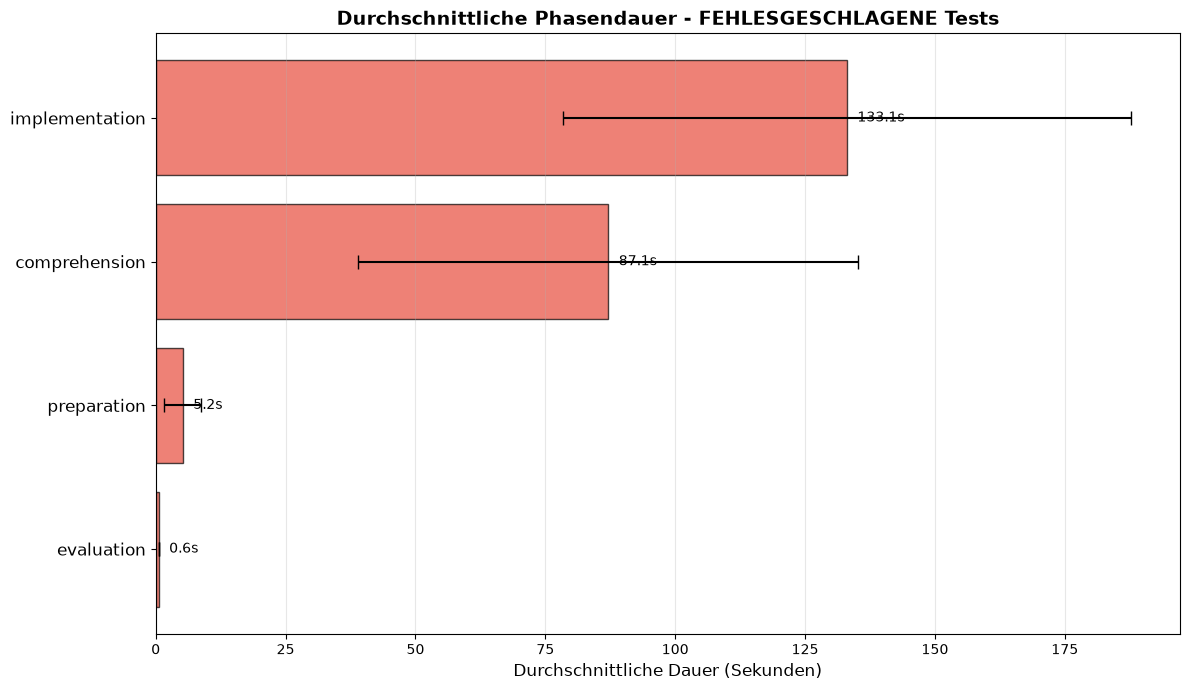

In [42]:
if len(df_phases) > 0:
    # Grafik 1: Durchschnittliche Phasendauer für FEHLGESCHLAGENE Tests
    fig, ax = plt.subplots(figsize=(12, 7))
    
    failed_data = avg_phases[avg_phases['success'] == False].sort_values('avg_latency', ascending=True)
    
    colors_failed = ['#e74c3c' for _ in failed_data]
    ax.barh(
        range(len(failed_data)),
        failed_data['avg_latency'],
        xerr=failed_data['std_latency'],
        capsize=5,
        color=colors_failed,
        alpha=0.7,
        edgecolor='black',
    )
    
    ax.set_yticks(range(len(failed_data)))
    ax.set_yticklabels(failed_data['phase'], fontsize=12)
    ax.set_xlabel('Durchschnittliche Dauer (Sekunden)', fontsize=12)
    ax.set_title('Durchschnittliche Phasendauer - FEHLESGESCHLAGENE Tests', fontsize=14, weight='bold')
    ax.grid(True, axis='x', alpha=0.3)
    
    # Werte hinzufügen
    for i, (_, row) in enumerate(failed_data.iterrows()):
        ax.text(row['avg_latency'] + 2, i, f"{row['avg_latency']:.1f}s", va='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'benchmark_phase_timing_failed.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Keine Phasen-Daten verfügbar.')

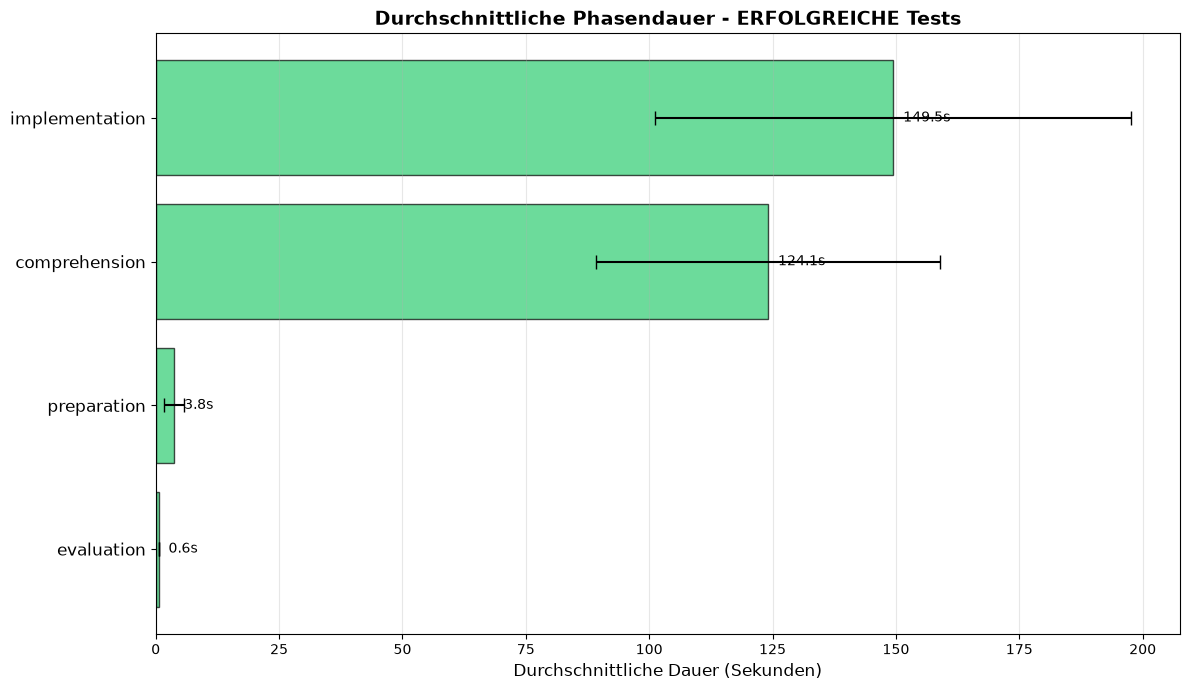

In [43]:
if len(df_phases) > 0:
    # Grafik 2: Durchschnittliche Phasendauer für ERFOLGREICHE Tests
    fig, ax = plt.subplots(figsize=(12, 7))
    
    success_data = avg_phases[avg_phases['success'] == True].sort_values('avg_latency', ascending=True)
    
    colors_success = ['#2ecc71' for _ in success_data]
    ax.barh(
        range(len(success_data)),
        success_data['avg_latency'],
        xerr=success_data['std_latency'],
        capsize=5,
        color=colors_success,
        alpha=0.7,
        edgecolor='black',
    )
    
    ax.set_yticks(range(len(success_data)))
    ax.set_yticklabels(success_data['phase'], fontsize=12)
    ax.set_xlabel('Durchschnittliche Dauer (Sekunden)', fontsize=12)
    ax.set_title('Durchschnittliche Phasendauer - ERFOLGREICHE Tests', fontsize=14, weight='bold')
    ax.grid(True, axis='x', alpha=0.3)
    
    # Werte hinzufügen
    for i, (_, row) in enumerate(success_data.iterrows()):
        ax.text(row['avg_latency'] + 2, i, f"{row['avg_latency']:.1f}s", va='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'benchmark_phase_timing_success.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Keine Phasen-Daten verfügbar.')

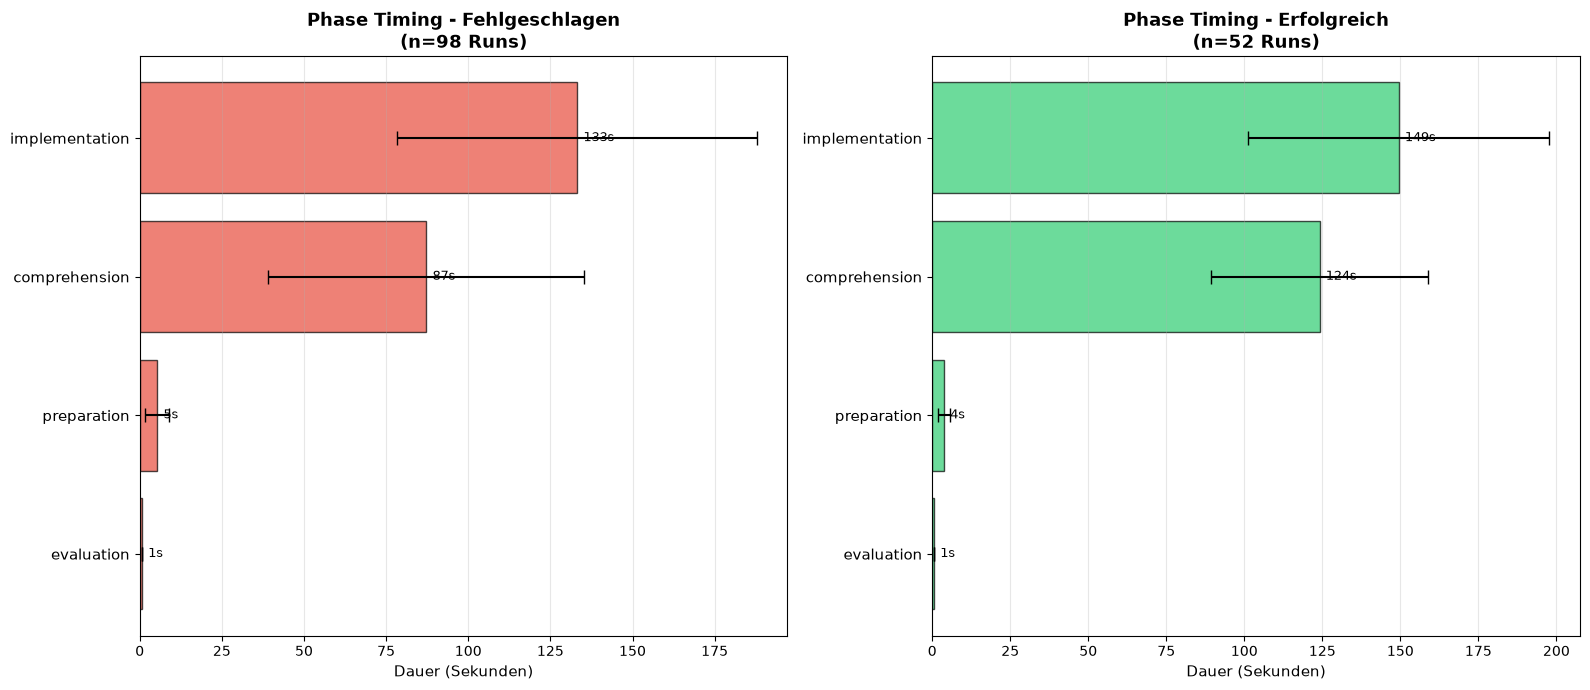

In [44]:
if len(df_phases) > 0:
    # Vergleichsgrafik: Erfolg vs. Misserfolg auf einer Achse
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    for idx, (label, filter_val, color) in enumerate([
        ('Fehlgeschlagen', False, '#e74c3c'),
        ('Erfolgreich', True, '#2ecc71'),
    ]):
        subset = avg_phases[avg_phases['success'] == filter_val].sort_values('avg_latency', ascending=True)
        
        axes[idx].barh(
            range(len(subset)),
            subset['avg_latency'],
            xerr=subset['std_latency'],
            capsize=5,
            color=color,
            alpha=0.7,
            edgecolor='black',
        )
        
        axes[idx].set_yticks(range(len(subset)))
        axes[idx].set_yticklabels(subset['phase'], fontsize=11)
        axes[idx].set_xlabel('Dauer (Sekunden)', fontsize=11)
        axes[idx].set_title(f'Phase Timing - {label}\n(n={int(subset["count"].sum())} Runs)', fontsize=13, weight='bold')
        axes[idx].grid(True, axis='x', alpha=0.3)
        
        for i, (_, row) in enumerate(subset.iterrows()):
            axes[idx].text(row['avg_latency'] + 2, i, f"{row['avg_latency']:.0f}s", va='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'benchmark_phase_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Keine Phasen-Daten verfügbar für den Vergleich.')

## 7. Zusammenfassung & Erkenntnisse

In [45]:
# Zusammenfassung erstellen
summary = {
    'Gesamtzahl Models': len(df),
    'Erfolgreiche Models': int(success_count),
    'Fehlgeschlagene Models': int(failure_count),
    'Erfolgsrate': f'{success_rate:.1f}%',
    'Häufigster Fehler-Typ': error_type_counts.index[0] if len(error_type_counts) > 0 else 'N/A',
    'Häufigste Fehler-Anzahl': int(error_type_counts.iloc[0]) if len(error_type_counts) > 0 else 0,
    'Schnellstes Model': df.iloc[0]['model_id'] if len(df) > 0 else 'N/A',
    'Langsamstes Model': df.iloc[-1]['model_id'] if len(df) > 0 else 'N/A',
    'Gesamtlaufzeit (Sek)': round(df['time_diff_seconds'].max(), 1) if len(df) > 0 else 0,
    'Models ohne Abbrüche': ', '.join(df[df['success']]['model_id'].tolist()) if success_count > 0 else 'Keine'
}

summary_df = pd.DataFrame(list(summary.items()), columns=['Metrik', 'Wert'])
print('=' * 60)
print('ZUSAMMENFASSUNG')
print('=' * 60)
for _, row in summary_df.iterrows():
    print(f'{row["Metrik"]:30s}: {row["Wert"]}')
print('=' * 60)

ZUSAMMENFASSUNG
Gesamtzahl Models             : 50
Erfolgreiche Models           : 15
Fehlgeschlagene Models        : 35
Erfolgsrate                   : 30.0%
Häufigster Fehler-Typ         : OpenAITimeoutError
Häufigste Fehler-Anzahl       : 26
Schnellstes Model             : GaleneAI/Magistral-Small-2509-FP8-Dynamic
Langsamstes Model             : Qwen/Qwen3.8-27B-FP8
Gesamtlaufzeit (Sek)          : 1047.4
Models ohne Abbrüche          : GaleneAI/Magistral-Small-2509-FP8-Dynamic, gpt-oss-120b, gpt-oss-120b, gpt-oss-120b, gpt-oss-120b, gpt-oss-120b, gpt-oss-120b, gpt-oss-120b, RedHatAI/gemma-4-31B-it-FP8-block, google/gemma-4-E4B-it, google/gemma-4-E4B-it, google/gemma-4-E4B-it, google/gemma-4-E4B-it, google/gemma-4-E4B-it, google/gemma-4-E4B-it


In [46]:
# Empfehlung für nächste Schritte
print('\n' + '=' * 60)
print('EMPFEHLUNGEN FÜR WEITERE OPTIMIERUNGEN')
print('=' * 60)
print('\n1. FEHLER-ANALYSE:')
most_common_error = error_type_counts.index[0] if len(error_type_counts) > 0 else "N/A"
most_common_error_count = error_type_counts.iloc[0] if len(error_type_counts) > 0 else 0
print(f'   - Häufigster Fehler: {most_common_error} ({most_common_error_count}x)')
print('   - Empfohlung: Prüfe die Loop-Konfiguration und die maximale Iterationsanzahl.')
print('     Wiederholte Abbrüche deuten auf Probleme im Agent-Loop hin.')

print('\n2. MODELLE:')
successful_model_names = df[df["success"]]["model_id"].tolist()
print(f'   - {success_count}/{len(df)} Models haben den Test bestanden')
print(f'   - Erfolgreiche Models: {", ".join(successful_model_names)}')
print('   - Empfohlung: Analysiere die Prompt-Strukturen erfolgreicher Models.')

print('\n3. LEISTUNG:')
total_runtime = df["time_diff_seconds"].max() if len(df) > 0 else 0
print(f'   - Gesamtlaufzeit: {total_runtime:.1f} Sekunden')
print('   - Empfohlung: Parallelisierung erhöhen, um die Durchlaufzeit zu reduzieren.')

print('\n4. PHASEN-TIMING (LangFuse):')
if len(df_phases) > 0:
    print('   - Phasen-Daten wurden erfolgreich von LangFuse abgerufen.')
    print('   - Siehe Diagramme in benchmark_phase_timing_*.png')
else:
    print('   - Keine Phasen-Daten verfügbar. Prüfe die LangFuse-Konfiguration.')

print('\n5. EVALUATIONS:')
if len(successful_evals) > 0:
    print(f'   - Erfolgreich durchgeführte Evaluations: {list(successful_evals.index)}')
    print('   - Empfohlung: Evaluations-Checkliste für fehlgeschlagene Models erweitern.')
else:
    print('   - Keine erfolgreichen Evaluations verfügbar.')

print('\n' + '=' * 60)


EMPFEHLUNGEN FÜR WEITERE OPTIMIERUNGEN

1. FEHLER-ANALYSE:
   - Häufigster Fehler: OpenAITimeoutError (26x)
   - Empfohlung: Prüfe die Loop-Konfiguration und die maximale Iterationsanzahl.
     Wiederholte Abbrüche deuten auf Probleme im Agent-Loop hin.

2. MODELLE:
   - 15/50 Models haben den Test bestanden
   - Erfolgreiche Models: GaleneAI/Magistral-Small-2509-FP8-Dynamic, gpt-oss-120b, gpt-oss-120b, gpt-oss-120b, gpt-oss-120b, gpt-oss-120b, gpt-oss-120b, gpt-oss-120b, RedHatAI/gemma-4-31B-it-FP8-block, google/gemma-4-E4B-it, google/gemma-4-E4B-it, google/gemma-4-E4B-it, google/gemma-4-E4B-it, google/gemma-4-E4B-it, google/gemma-4-E4B-it
   - Empfohlung: Analysiere die Prompt-Strukturen erfolgreicher Models.

3. LEISTUNG:
   - Gesamtlaufzeit: 1047.4 Sekunden
   - Empfohlung: Parallelisierung erhöhen, um die Durchlaufzeit zu reduzieren.

4. PHASEN-TIMING (LangFuse):
   - Phasen-Daten wurden erfolgreich von LangFuse abgerufen.
   - Siehe Diagramme in benchmark_phase_timing_*.png

5. 